# Current injection and optimization functions

In [ ]:
%pip install neuron
from neuron.units import mV,ms,um # unit definition
from neuron import h, gui


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


ImportError: cannot import name 'linregress' from 'scipy.optimize' (/Users/samme/opt/anaconda3/lib/python3.9/site-packages/scipy/optimize/__init__.py)

In [60]:
import numpy as np
import plotly
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from scipy.optimize import minimize, differential_evolution,least_squares, curve_fit
from scipy.stats import linregress
import pandas as pd

In [ ]:
h.load_file("stdlib.hoc")
h.load_file("import3d.hoc")
def load_neuron_model(hoc_file_path):
    """
    Load a neuron model from a hoc file, set up the NEURON environment,
    and allow for flexible naming of the NEURON object.

    """
    # Import NEURON module and load the hoc file
    h.load_file(hoc_file_path)

    # Create a PlotShape object for visualization
    ps = h.PlotShape(True)
    ps.plot(plotly).show()

    neuron_obj = h
    return neuron_obj

hocpath = "/Users/samme/Library/CloudStorage/OneDrive-Emory/Lab/LGMD_project/code/Python_Neuron/LGMD_Complete_Construction_NodesRemoved.hoc"
LGMD1 = load_neuron_model(hocpath)

In [ ]:
def Check_neuron(neuron_obj, thres = 100):
    """
    Check for disconnection and large diamteter 
    """
    # Verify Neuron Topology and Connections
    print("Neuron Model Topology:")
    neuron_obj.topology()
    
    discon_secs = set()
    print("\nSection Connections:") 
    for sec in neuron_obj.allsec():
        print(f"\nSection: {sec.name()}")
        for i in range(sec.n3d()):
            parent = sec.parentseg()
            if parent:
                print(f"  - Connected to parent: {parent.sec.name()} at {parent.x}")
            else:
                print("  - No parent section (root section)")
                discon_secs.add(sec.name())
    if discon_secs:
        print("\nWARNING: The following sections are not connected to any parent section:")
        for sec in discon_secs:
            print(f"  - {sec}")

    # Check for Sections with Diameters Exceeding 100
    exceeding_segments = []
    diam = []
    for sec in neuron_obj.allsec():
        if hasattr(sec, 'diam'):  # Ensure seg has a 'diam' property
            sec_diam = sec.diam
            diam.append(sec_diam)  # Collect segment diameters
                
            if sec_diam >= thres:
                exceeding_segments.append(f"{sec.name()}")
                print(f"\nWARNING: {sec.name()} exceeds {thres} μm in diameter. Actual: {sec_diam}")
            if sec_diam <=1:
                print(f"\nWARNING: {sec.name()} smaller than 1 μm in diameter. Actual: {sec_diam}")
    diam = np.array(diam)  
    return exceeding_segments, diam

exceeding_segments, diam = Check_neuron(LGMD1)

In [ ]:
# correct wrong diameter 
def correct_segment_diameters(neuron_obj, exceeding_segments, corrected_diameters):
    if len(exceeding_segments) != len(corrected_diameters):
        raise ValueError("The number of exceeding segments and corrected diameters must be the same.")

    segment_map = {seg: new_diam for seg, new_diam in zip(exceeding_segments, corrected_diameters)}
    diam = []
    for sec in neuron_obj.allsec():
        sec_name = f"{sec.name()}"
        if sec_name in segment_map:
            print(f"Correcting diameter of {sec_name} from {sec.diam} to {segment_map[sec_name]}")
            sec.diam = segment_map[sec_name]
        sec_diam = sec.diam
        diam.append(sec_diam)
    print("\nDiameter correction completed.")   
    plt.plot (diam)

correct_segment_diameters(LGMD1, exceeding_segments, [7.80, 13.40, 4.0])

#for sec in h.allsec():
    #print(f"Section: {sec.name()}")
    #print(sec.psection())
    #print("-" * 50)

In [105]:
## Main functions for current injection and optimization
def define_pass (model, Cm,Rm,Ra):
    for sec in model.allsec():  # Iterate over all sections in the model
        sec.insert('pas')       # Insert passive mechanism
        sec.Ra = Ra             # Set axial resistance
        sec.cm = Cm             # Set membrane capacitance
        sec.g_pas = 1.0 / Rm    # Set membrane conductance (1/Rm)
        sec.e_pas = -65 

def record_segment(inj_site, current = -0.2, duration= 3250, 
                   stim_dur = 1500, delay = 250, init_vm=-65, delta_t=0.05):
    # Set simulation parameters
    h.tstop = duration  # Total duration in ms
    h.v_init = init_vm  # Initial V_m (mV)
    h.dt = delta_t      # Time step for simulation (ms)

    # Create current clamp at the specified segment
    stim = h.IClamp(inj_site)
    stim.delay = delay      # Start of stimulus (ms)
    stim.dur = stim_dur     # Duration of stimulus (ms)
    stim.amp = current      # Amplitude of stimulus (nA)

    # Record membrane potential and time
    v_vec = h.Vector()      # V_m vector
    t_vec = h.Vector()      # Time vector
    recor_site = inj_site
    v_vec.record(recor_site._ref_v)
    t_vec.record(h._ref_t)

    # Initialize and run the simulation
    h.finitialize(h.v_init)
    h.continuerun(h.tstop)

    return np.array(v_vec), np.array(t_vec)

# Main optimization function for finding Ra and Rm
def opt_params(Allvol, AllCurrent, x0, bounds, inj_site, tau, fitted_region=None, 
               duration=3250, stim_dur=1500, delay=250, init_vm=-65, delta_t=0.05):   
    mse_val = []

    # Validate input sizes
    if len(Allvol) != len(AllCurrent):
        raise ValueError(f"Mismatch: {len(Allvol)} voltage traces vs {len(AllCurrent)} current values.")

    def obj_function(params):
        Rm, Ra = params
        tau_sec = tau * 1e-3  # ms to s
        Cm = (tau_sec / Rm) * 1e6  # in µF/cm²

        print(f"Trying - Ra: {Ra:.2f}, Cm: {Cm:.3f} µF/cm², Rm: {Rm:.2f} Ω·cm²")

        # Set passive properties
        for sec in h.allsec():
            sec.insert('pas')
            sec.Ra = Ra
            sec.cm = Cm
            sec.g_pas = 1 / Rm

        total_mse = 0
        for i, (curve2fit, current) in enumerate(zip(Allvol, AllCurrent)):
            v_sim, _ = record_segment(inj_site, current, duration, 
                                      stim_dur, delay, init_vm, delta_t)

            if fitted_region is None:
                residuals = curve2fit - v_sim
                mean_vol = np.mean(curve2fit)
            else:
                start, end = fitted_region
                residuals = curve2fit[start:end] - v_sim[start:end]
                mean_vol = np.mean(curve2fit[start:end])
            
            # Per-trace normalized MSE (squared residuals / mean voltage)
            mse = np.mean(residuals ** 2) #/ np.abs(mean_vol)
            mse_val.append(mse)
            total_mse += mse

        # Average MSE across all current conditions
        avg_mse = total_mse / len(Allvol)
        print(f"Avg MSE across traces: {avg_mse:.6f}")
        return avg_mse

    # Run optimization
    result = minimize(fun=obj_function, x0=x0, method='L-BFGS-B', 
                      bounds=bounds, options={'disp': True})

    # Extract and report parameters
    Rm_opt, Ra_opt = result.x
    Cm_opt = (tau * 1e-3 / Rm_opt) * 1e6  # in µF/cm²

    print(f"\nOptimized parameters:\nRa = {Ra_opt:.2f} Ω·cm\nRm = {Rm_opt:.2f} Ω·cm²\nCm = {Cm_opt:.3f} µF/cm²")

    return result, mse_val

# Fit time consntat tau
def fit_tau(exp_t, exp_v, title, V_steady, transient_start=50, transient_end=70):
    # time constant tau exponential equation: V_steady + (V_rest - V_steady) * np.exp(-(t) / tau)
    mask = (exp_t >= transient_start) & (exp_t <= transient_end)
    t_fit = exp_t[mask]
    v_fit = exp_v[mask]

    y = v_fit - V_steady
    valid = y > 0
    t_valid = t_fit[valid] - transient_start
    y_valid = np.log(y[valid])

    # linear regression
    slope, intercept, _, _, _ = linregress(t_valid, y_valid)
    tau = -1 / slope

    plt.figure(figsize=(8, 5))
    plt.plot(t_valid, y_valid, label='log(V - V_steady)')
    plt.plot(t_valid, slope * t_valid + intercept, '--', label=f'Linear fit: τ = {tau:.2f} ms')
    plt.xlabel('Time (ms)')
    plt.ylabel('ln(V - V_steady)')
    plt.title(title)
    plt.legend(), plt.grid(True), plt.tight_layout(), plt.show()

    return tau, intercept


# Exponential fit to find tau
#def exp_decay(t, tau, V_steady, V_rest):  
    #return V_steady + (V_rest - V_steady) * np.exp(-(t) / tau)

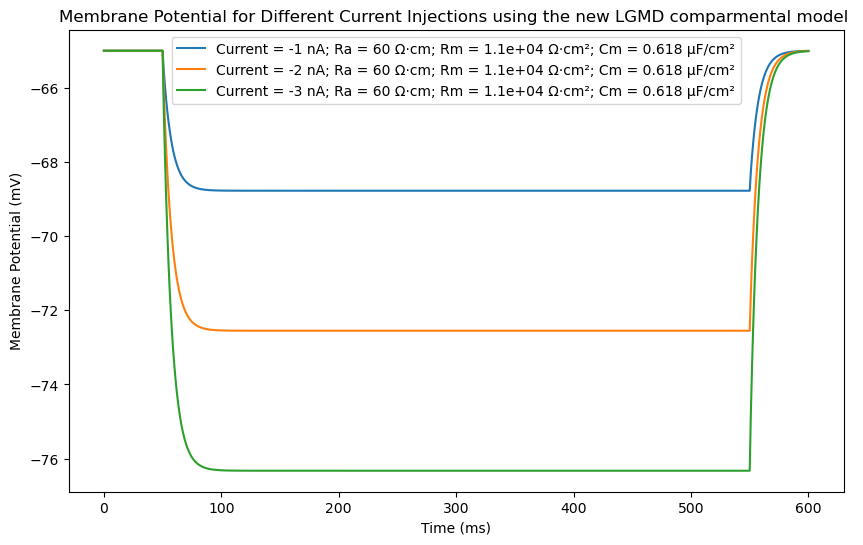

In [104]:
V_m = -65        # Resting membrane potential in mV
R_m = 11000   # Specific membrane resistivity in Ohm·cm²
C_m = 1.5       # Specific membrane capacitance in µF/cm² ( Should be <= 1)
tau = 6.8 #ms
C_m = tau*(1e-3)/R_m * 1e6 
R_a = 60     # Axial resistance in Ohm·cm # Something wrong with this parameter
G_pas = 1 / R_m  # Passive leaky conductance in S/cm²
current_values = [-1,-2, -3]

define_pass(LGMD1, C_m, R_m, R_a)

all_voltages = []
all_times = []
inj_site = LGMD1.FieldA[809](0.5) # base of field A # Diameter = 25.8
#inj_site = LGMD1.soma[0](0.5)

# Loop through each current value
for current in current_values:
    v_vec, t_vec = record_segment(inj_site, current=current, duration= 600, 
                stim_dur = 500, delay = 50, init_vm=V_m,delta_t=1)
    all_voltages.append(np.array(v_vec))
    all_times.append(np.array(t_vec))

plt.figure(figsize=(10, 6))
for i, current in enumerate(current_values):
    plt.plot(all_times[i], all_voltages[i], label=(
        f"Current = {current:.3g} nA; "
        f"Ra = {R_a:.3g} Ω·cm; "
        f"Rm = {R_m:.3g} Ω·cm²; "
        f"Cm = {C_m:.3g} μF/cm²"
    ))

plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (mV)")
plt.title("Membrane Potential for Different Current Injections using the new LGMD comparmental model ")
plt.legend()
plt.show()

# Fit to peron, 2007 experimental data

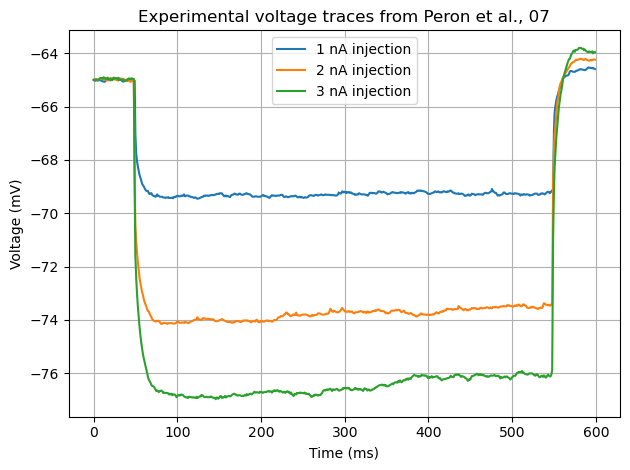

Number of time points truncated for all experimental traces= 602


In [ ]:
paths = [
    '/Users/samme/Library/CloudStorage/OneDrive-Emory/Lab/LGMD_project/LGMD_Data/Passive_CurrentClamp/um1na.txt',
    '/Users/samme/Library/CloudStorage/OneDrive-Emory/Lab/LGMD_project/LGMD_Data/Passive_CurrentClamp/um2na.txt',
    '/Users/samme/Library/CloudStorage/OneDrive-Emory/Lab/LGMD_project/LGMD_Data/Passive_CurrentClamp/um3na.txt']

all_time = []
all_voltage = []

min_len = float('inf')

for path in paths:
    df = pd.read_csv(path, delim_whitespace=True, header=None)
    time = df[0].values
    voltage = df[1].values

    min_len = min(min_len, len(time), len(voltage))

    all_time.append(time)
    all_voltage.append(voltage)
    
all_time = [t[:min_len] for t in all_time]
all_voltage = [v[:min_len] for v in all_voltage]

for i, voltage in enumerate(all_voltage):
    plt.plot(all_time[0], voltage, label=f'{i+1} nA injection')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title('Experimental voltage traces from Peron et al., 07')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print (f'Number of time points truncated for all experimental traces= {min_len}')

# Find time constant through fitting a single exponential
V(t) = V_Rest + (V_Steady - V_rest) * (1- exp(-t/tau))


Fitting trace 1...
v_steady = -69.39909849058823 for trace 0; ln(V_rest - V_steady) = 1.4813996314290236


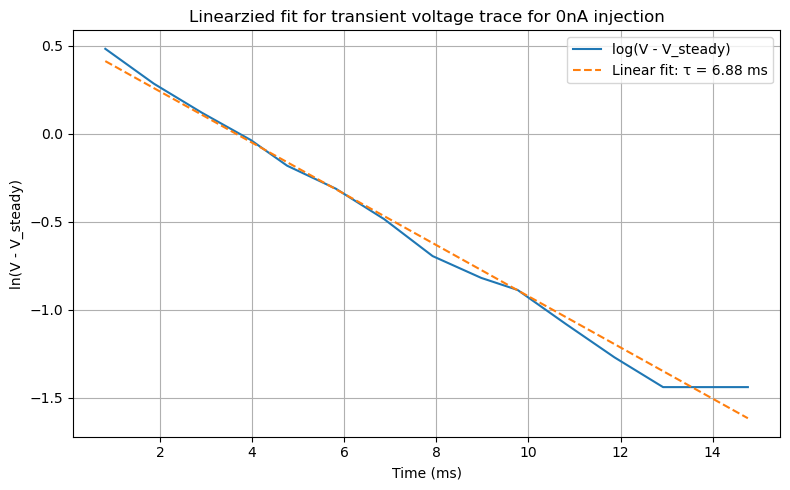

Trace 1: τ = 6.88 ms

Fitting trace 2...
v_steady = -74.03157537208142 for trace 1; ln(V_rest - V_steady) = 2.200726812022232


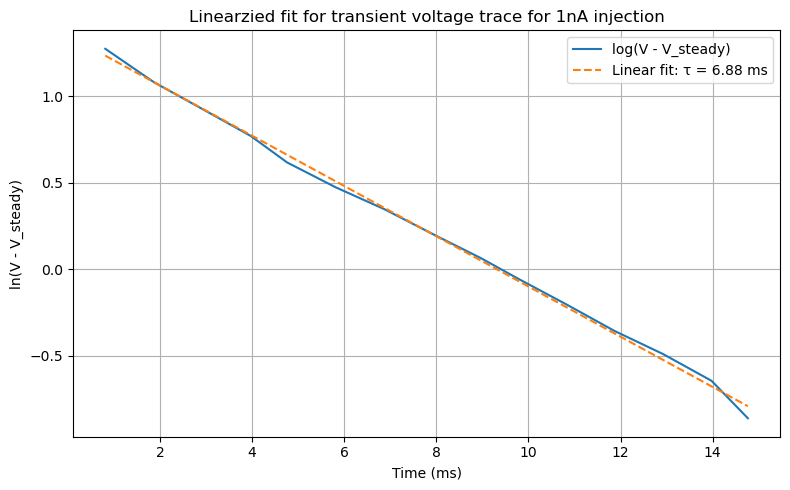

Trace 2: τ = 6.88 ms

Fitting trace 3...
v_steady = -76.90062153503811 for trace 2; ln(V_rest - V_steady) = 2.476590628588689


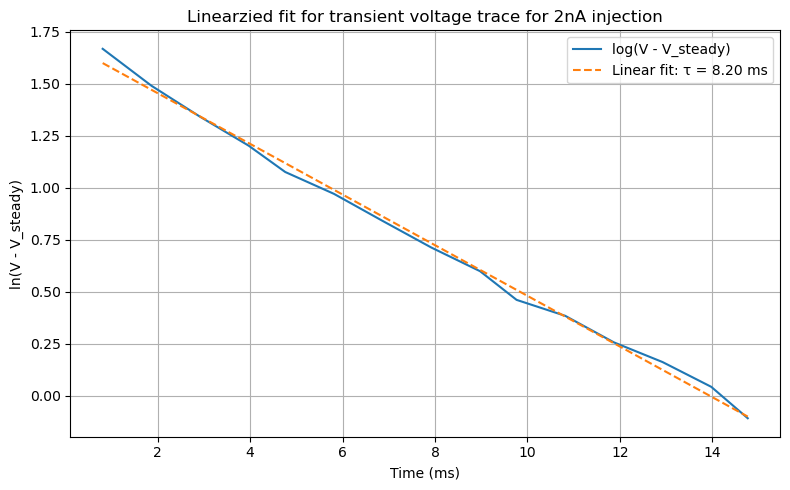

Trace 3: τ = 8.20 ms


In [88]:
# Need to omit the first few ms due to the effect of tau_equalization (through Ra)
transient_start=50
transient_end=65
taus = []
interps = []

for i, (exp_t, exp_v) in enumerate(zip(all_time, all_voltage)):
    print(f"\nFitting trace {i + 1}...")

    v_steady = np.mean(exp_v[transient_end+50:transient_end+60])
    b = np.log(-65 - v_steady)
    print(f'v_steady = {v_steady} for trace {i}; ln(V_rest - V_steady) = {b}')
    
    title = f'Linearzied fit for transient voltage trace for {i}nA injection'
    tau, intercept = fit_tau(exp_t,
    exp_v, title, v_steady, transient_start=transient_start,
    transient_end=transient_end)

    print(f"Trace {i+1}: τ = {tau:.2f} ms")
    taus.append(tau)
    interps.append(intercept)

Trying - Ra: 60.00, Cm: 0.680 µF/cm², Rm: 10000.00 Ω·cm²
Avg MSE across traces: 2.086525
Trying - Ra: 60.00, Cm: 0.680 µF/cm², Rm: 10000.00 Ω·cm²
Avg MSE across traces: 2.086525
Trying - Ra: 60.00, Cm: 0.680 µF/cm², Rm: 10000.00 Ω·cm²
Avg MSE across traces: 2.086525
Trying - Ra: 60.00, Cm: 0.680 µF/cm², Rm: 10000.00 Ω·cm²
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            2     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.08653D+00    |proj g|=  4.50213D-03
Avg MSE across traces: 2.086502
Trying - Ra: 60.00, Cm: 0.680 µF/cm², Rm: 10000.00 Ω·cm²
Avg MSE across traces: 2.086502
Trying - Ra: 60.00, Cm: 0.680 µF/cm², Rm: 10000.00 Ω·cm²
Avg MSE across traces: 2.086502
Trying - Ra: 60.01, Cm: 0.680 µF/cm², Rm: 10000.00 Ω·cm²

At iterate    1    f=  2.08650D+00    |proj g|=  4.50298D-03
  ys=-1.642E-07  -gs= 2.314E-05 BFGS update SKIPPED
Avg MSE across traces: 2.086478
Trying - Ra: 60.01, Cm: 0.680 µF/c

Text(0.5, 1.0, 'MSE over iterations')

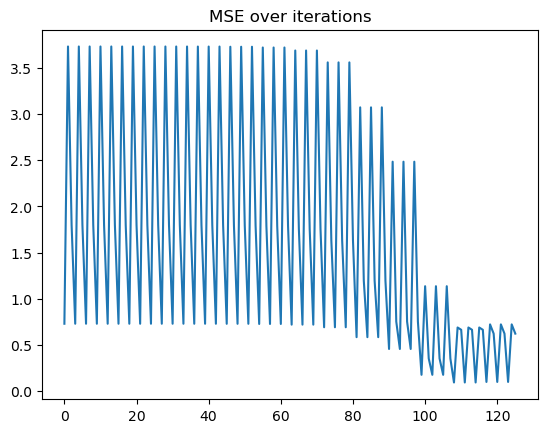

In [ ]:
# Perform the fit
exp_delt = 1 #ms
region = [1,500]
tau = 6.5
# Rm, Ra 
bounds = [(3000, 20000), (50,200)]
x0 = [10000, 60] # Initial guess
AllCurrent = [-1,-2,-3]
#parms, mse = opt_params (exp_v,x0, bounds, inj_site, tau, current = -1, fitted_region = region, duration= 600, 
                #stim_dur = 500, delay = 50, init_vm=-65, delta_t= exp_delt)
parms, mse = opt_params(all_voltage, AllCurrent, x0, bounds, inj_site, tau, fitted_region=region, 
               duration= 600, stim_dur = 500, delay = 50, init_vm=-65, delta_t= exp_delt) 

plt.plot (mse)
plt.title ('MSE over iterations')

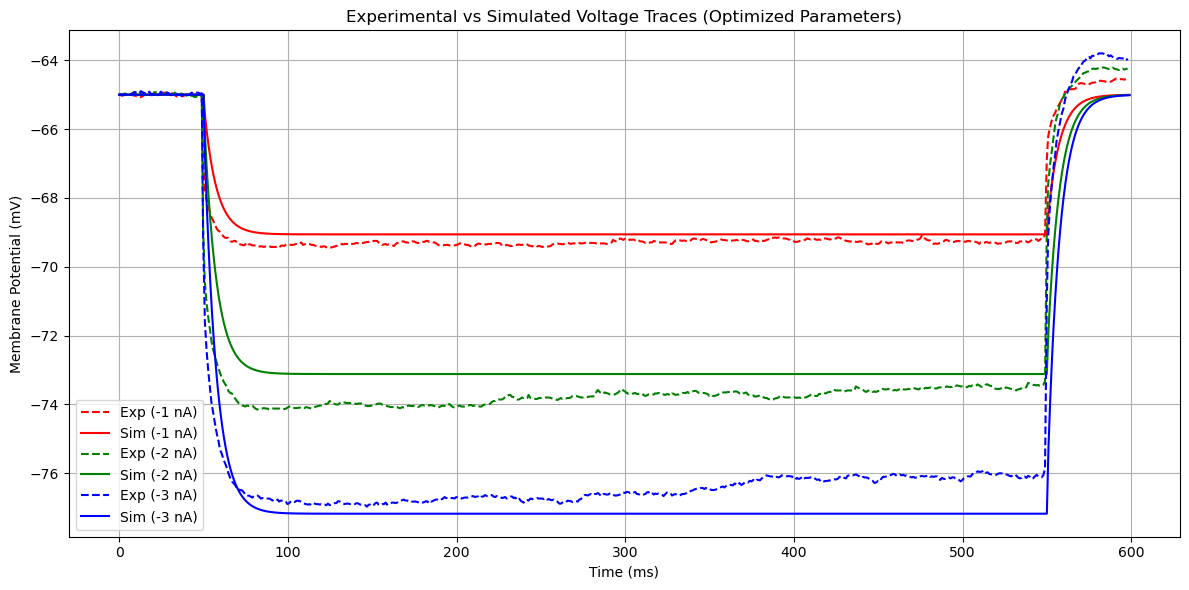

In [113]:
# Cm, Rm, Ra
Ra_opt = parms.x[1]
Rm_opt = parms.x[0]
Cm_opt = tau * 1e-3 / Rm_opt * 1e6  # F/cm² → µF/cm²

define_pass(LGMD1, Cm_opt, Rm_opt, Ra_opt)

inj_site = LGMD1.FieldA[809](0.5)  # base of field A
current_val = [-1, -2, -3]  # nA

# Assume all_voltage and all_time already contain experimental traces
# If not, you can load them or simulate them separately

plt.figure(figsize=(12, 6))
colors = ['r', 'g', 'b']

for i, current in enumerate(current_val):
    # Simulated
    v_vec, t_vec = record_segment(inj_site, current=current, duration=600,
                                   stim_dur=500, delay=50, init_vm=V_m, delta_t=1)
    v_vec = np.array(v_vec)
    t_vec = np.array(t_vec)

    # Experimental
    exp = all_voltage[i]
    t_exp = all_time[i]

    plt.plot(t_exp[:600], exp[:600], linestyle='--', color=colors[i], label=f'Exp ({current} nA)')
    plt.plot(t_vec[:600], v_vec[:600], linestyle='-', color=colors[i], label=f'Sim ({current} nA)')

plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (mV)")
plt.title("Experimental vs Simulated Voltage Traces (Optimized Parameters)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

